In [6]:
import pandas as pd
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
cols_to_clean = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols_to_clean] = df[cols_to_clean].replace(0, np.nan)

In [9]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [10]:
df_clean = df.dropna().copy()
df_clean.shape

(392, 9)

In [11]:
df_clean = df.copy()
for col in cols_to_clean:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [12]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

# Check Logistic Regression results
print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(classification_report(y_test, y_pred_lr))

# Check Random Forest results
print("\n--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression ---
Accuracy: 0.70
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


--- Random Forest ---


NameError: name 'y_pred_rf' is not defined

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_rf)

# Print the results
print("--- Random Forest ---")
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred_rf))

--- Random Forest ---
Accuracy: 0.74
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [19]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [21]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [22]:
from xgboost import XGBClassifier

# Train XGBoost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Show XGBoost results
print("--- XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost ---
Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

print("LR:", evaluate_model(y_test, y_pred_lr))
print("RF:", evaluate_model(y_test, y_pred_rf))
print("XGB:", evaluate_model(y_test, y_pred_xgb))

LR: {'accuracy': 0.7012987012987013, 'precision': 0.5869565217391305, 'recall': 0.5, 'f1': 0.54}
RF: {'accuracy': 0.7402597402597403, 'precision': 0.6521739130434783, 'recall': 0.5555555555555556, 'f1': 0.6}
XGB: {'accuracy': 0.7597402597402597, 'precision': 0.673469387755102, 'recall': 0.6111111111111112, 'f1': 0.6407766990291263}


In [24]:
import shap
import numpy as np
import matplotlib.pyplot as plt

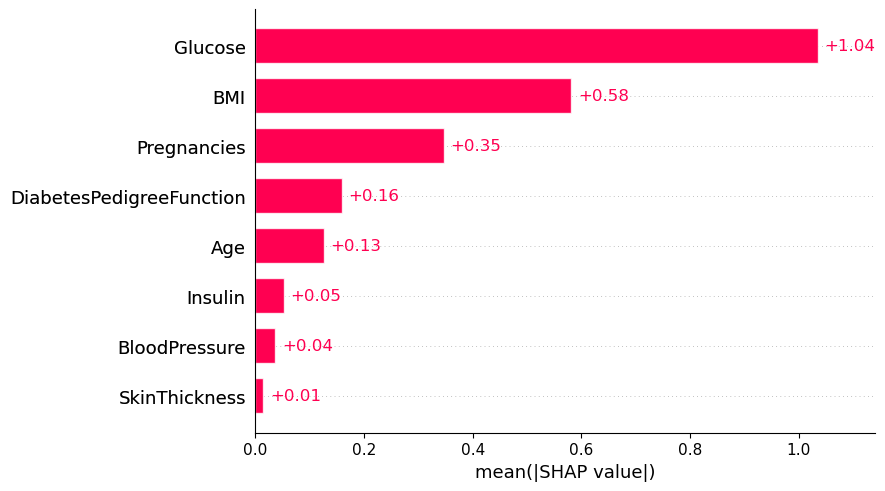

In [25]:
explainer_lr = shap.Explainer(lr, X_train)
shap_values_lr = explainer_lr(X_test)

shap.plots.bar(shap_values_lr)
plt.show()

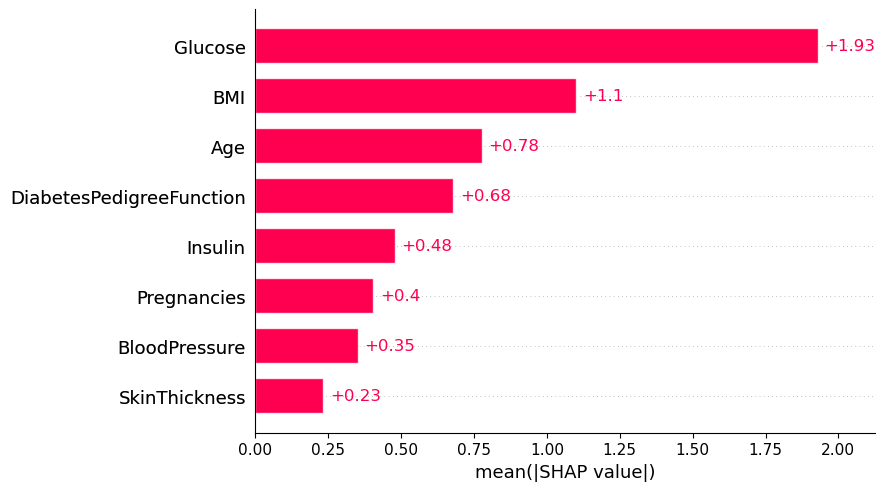

In [26]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb(X_test)

shap.plots.bar(shap_values_xgb)
plt.show()

In [27]:
# Try plotting just for one class
shap.plots.bar(shap_values_rf[:, :, 0])

NameError: name 'shap_values_rf' is not defined

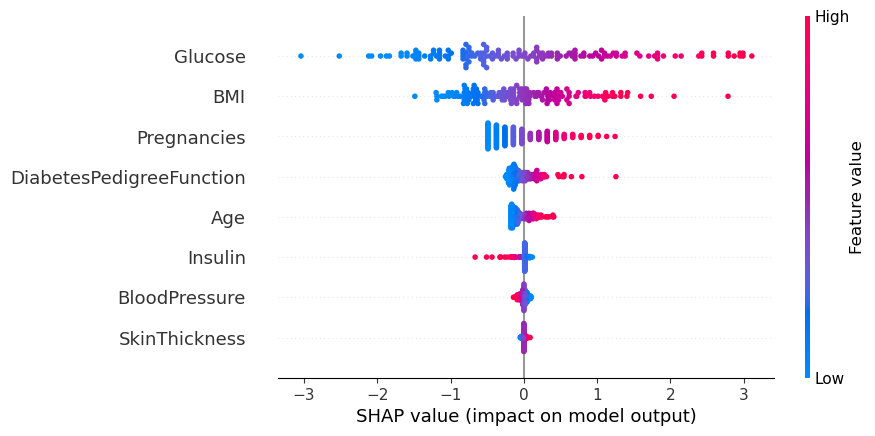

NameError: name 'shap_values_rf' is not defined

In [28]:
shap.plots.beeswarm(shap_values_lr)
shap.plots.beeswarm(shap_values_rf)
shap.plots.beeswarm(shap_values_xgb)

In [ ]:
shap.summary_plot(shap_values_xgb.values, X_test, plot_type="bar", show=False)
plt.savefig("xgb_shap_bar.png", dpi=300, bbox_inches="tight")
plt.close()

In [29]:
import matplotlib.pyplot as plt

# 1. Create the plot (don't forget the indexing [:, :, 1] if it's a classifier!)
shap.plots.bar(shap_values_rf[:, :, 1], show=False)

# 2. Save it to your computer
plt.savefig("rf_shap_bar.png", dpi=300, bbox_inches="tight")

# 3. Close it so it doesn't mess up the next plot
plt.close()

NameError: name 'shap_values_rf' is not defined

In [30]:
# 1. Create the LR plot
shap.plots.bar(shap_values_lr, show=False)

# 2. Save
plt.savefig("lr_shap_bar.png", dpi=300, bbox_inches="tight")

# 3. Close
plt.close()

In [31]:
# 1. Try plotting without the extra index
# If this works, it means your XGBoost output was 2D, not 3D
shap.plots.bar(shap_values_xgb, show=False)

# 2. Save it
plt.savefig("xgb_shap_bar.png", dpi=300, bbox_inches="tight")

# 3. Close
plt.close()

In [32]:
# 1. Update the list with real names from your image
lr_top_5_cols = ['Glucose', 'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'Age']

# 2. Subset the data
X_train_lr5 = X_train[lr_top_5_cols]
X_test_lr5 = X_test[lr_top_5_cols]

# 3. Initialize and Retrain Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_5 = LogisticRegression(max_iter=1000)
lr_5.fit(X_train_lr5, y_train)

# 4. Check the performance
y_pred_lr5 = lr_5.predict(X_test_lr5)
print(f"5-Variable Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr5):.4f}")

5-Variable Logistic Regression Accuracy: 0.7013


In [33]:
# Optional: Try a very simple 3-variable model
lr_top_3_cols = ['Glucose', 'BMI', 'Pregnancies']

X_train_lr3 = X_train[lr_top_3_cols]
X_test_lr3 = X_test[lr_top_3_cols]

lr_3 = LogisticRegression()
lr_3.fit(X_train_lr3, y_train)

y_pred_lr3 = lr_3.predict(X_test_lr3)
print(f"3-Variable Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr3):.4f}")

3-Variable Logistic Regression Accuracy: 0.7078


In [34]:
# 1. Update the list with the RF-specific top features from your new image
rf_top_5_cols = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']

# 2. Subset the data
X_train_rf5 = X_train[rf_top_5_cols]
X_test_rf5 = X_test[rf_top_5_cols]

# 3. Initialize and Retrain Random Forest
from sklearn.ensemble import RandomForestClassifier

# Using random_state=42 ensures you get the same result every time you run it
rf_5 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_5.fit(X_train_rf5, y_train)

# 4. Check the performance
y_pred_rf5 = rf_5.predict(X_test_rf5)
print(f"5-Variable Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf5):.4f}")

5-Variable Random Forest Accuracy: 0.7338


In [35]:
# 1. Select the top features from your XGBoost SHAP plot
xgb_top_5_cols = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']

# 2. Subset the data
X_train_xgb5 = X_train[xgb_top_5_cols]
X_test_xgb5 = X_test[xgb_top_5_cols]

# 3. Initialize and Retrain XGBoost
from xgboost import XGBClassifier

# We use a fresh model instance to ensure no 'memory' of the old features remains
xgb_5 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_5.fit(X_train_xgb5, y_train)

# 4. Check the performance
y_pred_xgb5 = xgb_5.predict(X_test_xgb5)
print(f"5-Variable XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb5):.4f}")

/home/25100f40-98b0-48d9-bea8-dd67bcc1851c/.local/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:43:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


5-Variable XGBoost Accuracy: 0.7273


In [36]:
# Run this to see how they stack up side-by-side
print("--- FINAL 5-VARIABLE RESULTS ---")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr5):.4f}")
print(f"Random Forest:       {accuracy_score(y_test, y_pred_rf5):.4f}")
print(f"XGBoost:             {accuracy_score(y_test, y_pred_xgb5):.4f}")

--- FINAL 5-VARIABLE RESULTS ---
Logistic Regression: 0.7013
Random Forest:       0.7338
XGBoost:             0.7273


In [37]:
explainer_lr = shap.Explainer(lr, X_train)

In [38]:
shap_values_lr = explainer_lr(X_test)

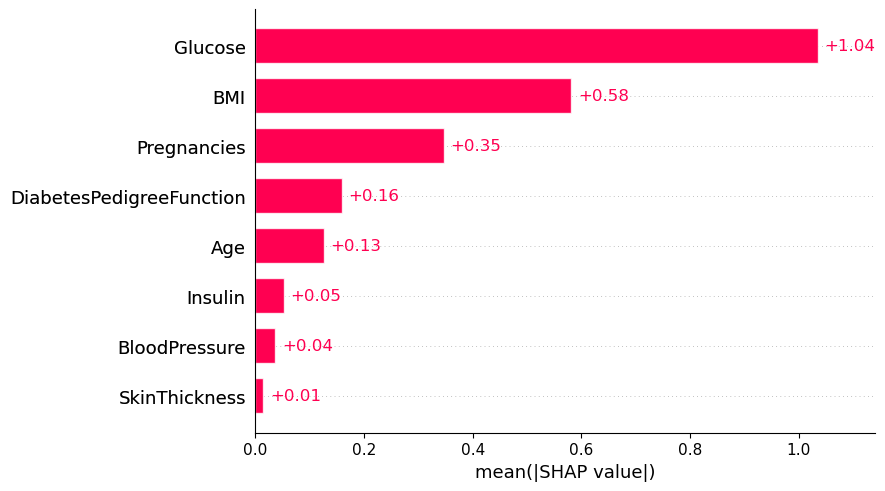

In [39]:
shap.plots.bar(shap_values_lr)

In [40]:
print(shap_values_lr.abs.mean(0).values)

[0.34625344 1.03556908 0.03649389 0.01437888 0.05209787 0.58174319
 0.15846255 0.12621638]


In [41]:
print(X_test.columns[np.argsort(shap_values_lr.abs.mean(0).values)[::-1]])

Index(['Glucose', 'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'Age',
       'Insulin', 'BloodPressure', 'SkinThickness'],
      dtype='object')


In [42]:
explainer_rf = shap.TreeExplainer(rf)

In [43]:
shap_values_rf = explainer_rf(X_test)

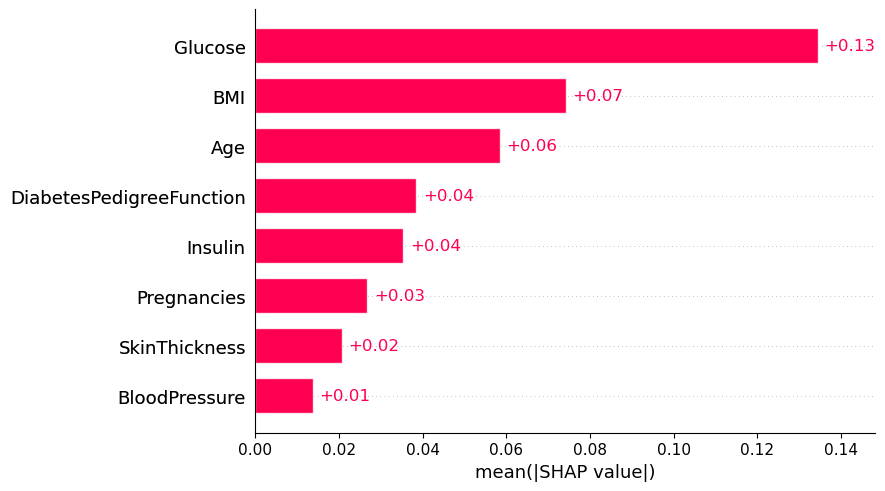

In [44]:
shap.plots.bar(shap_values_rf[:, :, 1])

In [45]:
print(shap_values_rf.abs.mean(0).values)

[[0.02672507 0.02672507]
 [0.1344402  0.1344402 ]
 [0.01368299 0.01368299]
 [0.02057185 0.02057185]
 [0.03533567 0.03533567]
 [0.07419576 0.07419576]
 [0.03846223 0.03846223]
 [0.05835279 0.05835279]]


In [46]:
print(X_test.columns[np.argsort(shap_values_rf[:, :, 1].abs.mean(0).values)[::-1]])

Index(['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin',
       'Pregnancies', 'SkinThickness', 'BloodPressure'],
      dtype='object')


In [47]:
explainer_xgb = shap.TreeExplainer(xgb)

In [48]:
shap_values_xgb = explainer_xgb(X_test)

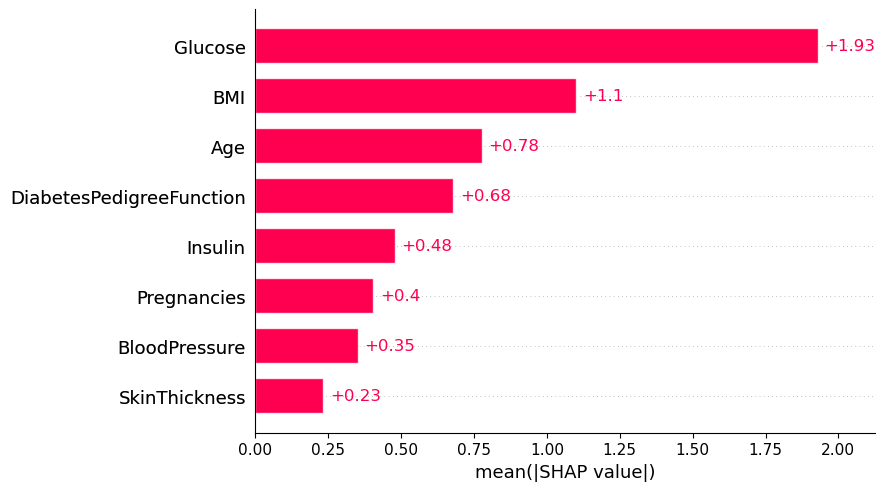

In [49]:
shap.plots.bar(shap_values_xgb)

In [50]:
print(shap_values_xgb.abs.mean(0).values)

[0.40477377 1.9294918  0.3504679  0.23296873 0.47758123 1.1006219
 0.67840564 0.7765531 ]


In [51]:
print(X_test.columns[np.argsort(shap_values_xgb.abs.mean(0).values)[::-1]])

Index(['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin',
       'Pregnancies', 'BloodPressure', 'SkinThickness'],
      dtype='object')


In [52]:
top5 = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction", "Pregnancies"]

X5 = df_clean[top5]
y = df_clean["Outcome"]

In [53]:
from sklearn.model_selection import train_test_split

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr5 = LogisticRegression(max_iter=1000, random_state=42)
lr5.fit(X5_train, y5_train)
pred_lr5 = lr5.predict(X5_test)

print("LR 5-variable accuracy:", accuracy_score(y5_test, pred_lr5))
print("Precision:", precision_score(y5_test, pred_lr5))
print("Recall:", recall_score(y5_test, pred_lr5))
print("F1:", f1_score(y5_test, pred_lr5))

LR 5-variable accuracy: 0.7012987012987013
Precision: 0.5869565217391305
Recall: 0.5
F1: 0.54


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf5 = RandomForestClassifier(n_estimators=200, random_state=42)
rf5.fit(X5_train, y5_train)
pred_rf5 = rf5.predict(X5_test)

print("RF 5-variable accuracy:", accuracy_score(y5_test, pred_rf5))
print("Precision:", precision_score(y5_test, pred_rf5))
print("Recall:", recall_score(y5_test, pred_rf5))
print("F1:", f1_score(y5_test, pred_rf5))

RF 5-variable accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.5925925925925926
F1: 0.6274509803921569


In [56]:
from xgboost import XGBClassifier

xgb5 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)
xgb5.fit(X5_train, y5_train)
pred_xgb5 = xgb5.predict(X5_test)

print("XGB 5-variable accuracy:", accuracy_score(y5_test, pred_xgb5))
print("Precision:", precision_score(y5_test, pred_xgb5))
print("Recall:", recall_score(y5_test, pred_xgb5))
print("F1:", f1_score(y5_test, pred_xgb5))

XGB 5-variable accuracy: 0.7207792207792207
Precision: 0.6122448979591837
Recall: 0.5555555555555556
F1: 0.5825242718446602


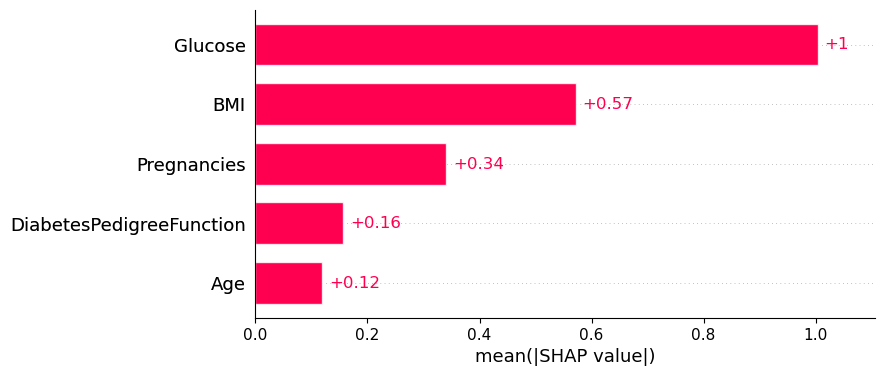

IndexError: list index out of range

In [57]:
import shap

explainer_lr5 = shap.Explainer(lr5, X5_train)
sv_lr5 = explainer_lr5(X5_test)
shap.plots.bar(sv_lr5)

explainer_rf5 = shap.TreeExplainer(rf5)
sv_rf5 = explainer_rf5(X5_test)
shap.plots.bar(sv_rf5)

explainer_xgb5 = shap.TreeExplainer(xgb5)
sv_xgb5 = explainer_xgb5(X5_test)
shap.plots.bar(sv_xgb5)

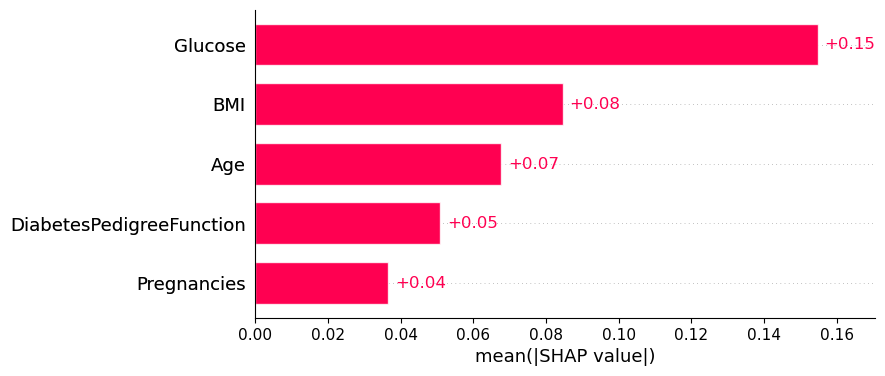

In [58]:
# Try plotting only the values for the second class (index 1)
shap.plots.bar(sv_rf5[:, :, 1])

In [59]:
# Use this for XGBoost since it only has 2 dimensions
shap.plots.bar(sv_xgb5)

NameError: name 'sv_xgb5' is not defined

In [60]:
X8 = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

In [61]:
from sklearn.model_selection import train_test_split

X8_train, X8_test, y8_train, y8_test = train_test_split(
    X8, y, test_size=0.2, random_state=42, stratify=y
)

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr8 = LogisticRegression(max_iter=1000, random_state=42)
lr8.fit(X8_train, y8_train)
pred_lr8 = lr8.predict(X8_test)

print("LR 8-variable accuracy:", accuracy_score(y8_test, pred_lr8))
print("Precision:", precision_score(y8_test, pred_lr8))
print("Recall:", recall_score(y8_test, pred_lr8))
print("F1:", f1_score(y8_test, pred_lr8))

LR 8-variable accuracy: 0.7012987012987013
Precision: 0.5869565217391305
Recall: 0.5
F1: 0.54


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf8 = RandomForestClassifier(n_estimators=200, random_state=42)
rf8.fit(X8_train, y8_train)
pred_rf8 = rf8.predict(X8_test)

print("RF 8-variable accuracy:", accuracy_score(y8_test, pred_rf8))
print("Precision:", precision_score(y8_test, pred_rf8))
print("Recall:", recall_score(y8_test, pred_rf8))
print("F1:", f1_score(y8_test, pred_rf8))

RF 8-variable accuracy: 0.7402597402597403
Precision: 0.6521739130434783
Recall: 0.5555555555555556
F1: 0.6


In [64]:
from xgboost import XGBClassifier

xgb8 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)
xgb8.fit(X8_train, y8_train)
pred_xgb8 = xgb8.predict(X8_test)

print("XGB 8-variable accuracy:", accuracy_score(y8_test, pred_xgb8))
print("Precision:", precision_score(y8_test, pred_xgb8))
print("Recall:", recall_score(y8_test, pred_xgb8))
print("F1:", f1_score(y8_test, pred_xgb8))

XGB 8-variable accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.5925925925925926
F1: 0.6274509803921569


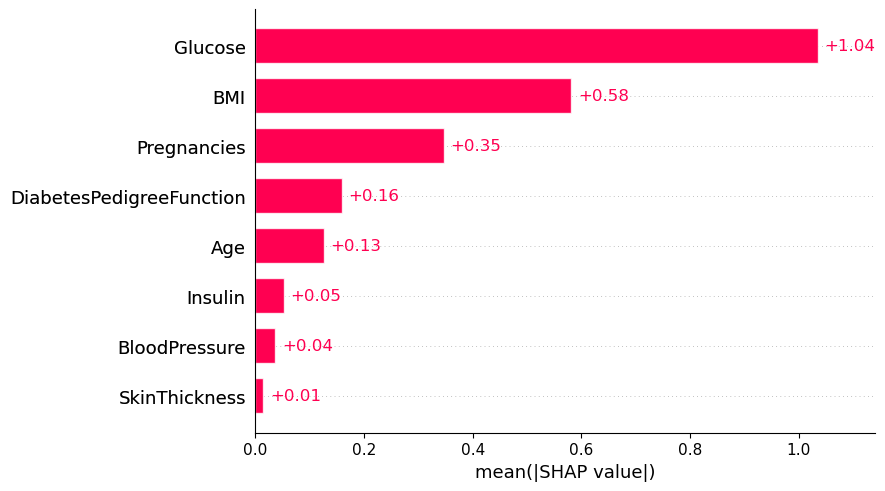

IndexError: list index out of range

In [65]:
import shap

explainer_lr8 = shap.Explainer(lr8, X8_train)
sv_lr8 = explainer_lr8(X8_test)
shap.plots.bar(sv_lr8)

explainer_rf8 = shap.TreeExplainer(rf8)
sv_rf8 = explainer_rf8(X8_test)
shap.plots.bar(sv_rf8)

explainer_xgb8 = shap.TreeExplainer(xgb8)
sv_xgb8 = explainer_xgb8(X8_test)
shap.plots.bar(sv_xgb8)

In [ ]:
# Change line 9 from:
# shap.plots.bar(sv_rf8)
# To:
shap.plots.bar(sv_rf8[:, :, 1])

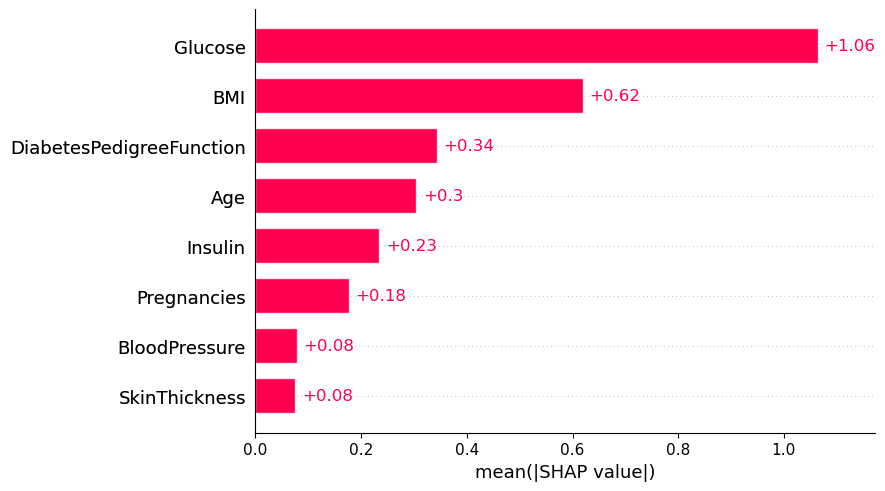

In [66]:
# 1. Create the explainer for your 8-variable XGBoost model
explainer_xgb8 = shap.TreeExplainer(xgb8)

# 2. Generate the SHAP values (This defines the missing 'sv_xgb8')
sv_xgb8 = explainer_xgb8(X8_test)

# 3. Try the plot (Starting without the slice, as XGBoost usually prefers 2D)
shap.plots.bar(sv_xgb8)

In [67]:
import joblib

joblib.dump(lr8, "lr8_model.pkl")
joblib.dump(rf8, "rf8_model.pkl")
joblib.dump(xgb8, "xgb8_model.pkl")

joblib.dump(lr5, "lr5_model.pkl")
joblib.dump(rf5, "rf5_model.pkl")
joblib.dump(xgb5, "xgb5_model.pkl")

['xgb5_model.pkl']

In [68]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(lr8, "models/lr8_model.pkl")
joblib.dump(rf8, "models/rf8_model.pkl")
joblib.dump(xgb8, "models/xgb8_model.pkl")
joblib.dump(lr5, "models/lr5_model.pkl")
joblib.dump(rf5, "models/rf5_model.pkl")
joblib.dump(xgb5, "models/xgb5_model.pkl")

['models/xgb5_model.pkl']

In [69]:
lr8 = joblib.load("lr8_model.pkl")
rf8 = joblib.load("rf8_model.pkl")
xgb8 = joblib.load("xgb8_model.pkl")

In [70]:
import joblib

In [71]:
joblib.dump(lr8, "lr8_model.pkl")

['lr8_model.pkl']

In [72]:
joblib.dump(rf8, "rf8_model.pkl")

['rf8_model.pkl']

In [73]:
joblib.dump(xgb8, "xgb8_model.pkl")

['xgb8_model.pkl']

In [74]:
joblib.dump(lr5, "lr5_model.pkl")

['lr5_model.pkl']

In [75]:
joblib.dump(rf5, "rf5_model.pkl")

['rf5_model.pkl']

In [76]:
joblib.dump(xgb5, "xgb5_model.pkl")

['xgb5_model.pkl']

In [77]:
import joblib

joblib.dump(lr8, "lr8_model.pkl")
joblib.dump(rf8, "rf8_model.pkl")
joblib.dump(xgb8, "xgb8_model.pkl")
joblib.dump(lr5, "lr5_model.pkl")
joblib.dump(rf5, "rf5_model.pkl")
joblib.dump(xgb5, "xgb5_model.pkl")

['xgb5_model.pkl']

In [78]:
import os

In [79]:
os.makedirs("models", exist_ok=True)

In [80]:
joblib.dump(lr8, "models/lr8_model.pkl")

['models/lr8_model.pkl']

In [81]:
os.makedirs("models", exist_ok=True)

joblib.dump(lr8, "models/lr8_model.pkl")
joblib.dump(rf8, "models/rf8_model.pkl")
joblib.dump(xgb8, "models/xgb8_model.pkl")

['models/xgb8_model.pkl']

In [82]:
os.makedirs("models", exist_ok=True)

joblib.dump(lr5, "models/lr5_model.pkl")
joblib.dump(rf5, "models/rf5_model.pkl")
joblib.dump(xgb5, "models/xgb5_model.pkl")

['models/xgb5_model.pkl']

In [83]:
joblib.dump(lr8, "models/lr8_model.pkl")

['models/lr8_model.pkl']

In [84]:
joblib.dump(rf8, "models/rf8_model.pkl")
joblib.dump(xgb8, "models/xgb8_model.pkl")
joblib.dump(lr5, "models/lr5_model.pkl")
joblib.dump(rf5, "models/rf5_model.pkl")
joblib.dump(xgb5, "models/xgb5_model.pkl")

['models/xgb5_model.pkl']

In [85]:
joblib.dump(rf8, "models/rf8_model.pkl")

['models/rf8_model.pkl']

In [86]:
joblib.dump(xgb8, "models/xgb8_model.pkl")

['models/xgb8_model.pkl']

In [87]:
joblib.dump(lr5, "models/lr5_model.pkl")

['models/lr5_model.pkl']

In [88]:
joblib.dump(rf5, "models/rf5_model.pkl")

['models/rf5_model.pkl']

In [89]:
joblib.dump(xgb5, "models/xgb5_model.pkl")

['models/xgb5_model.pkl']

In [90]:
import os
os.listdir("models")

['rf8_model.pkl',
 'xgb5_model.pkl',
 'lr5_model.pkl',
 'xgb8_model.pkl',
 'lr8_model.pkl',
 'rf5_model.pkl']

In [91]:
import os
os.getcwd()

'/home/25100f40-98b0-48d9-bea8-dd67bcc1851c/code'

In [92]:
import os
os.listdir()

['rf8_model.pkl',
 '.ipynb_checkpoints',
 'xgb5_model.pkl',
 'xgb_shap_bar.png',
 'diabetes_prediction.ipynb',
 'models',
 'Diabetes_prediction (1).ipynb',
 'lr5_model.pkl',
 'lr_shap_bar.png',
 'xgb8_model.pkl',
 'lr8_model.pkl',
 'rf5_model.pkl',
 'Diabetes_prediction.ipynb']

In [93]:
os.path.abspath("models/lr8_model.pkl")

'/home/25100f40-98b0-48d9-bea8-dd67bcc1851c/code/models/lr8_model.pkl'

In [94]:
os.path.abspath("models/lr8_model.pkl")

'/home/25100f40-98b0-48d9-bea8-dd67bcc1851c/code/models/lr8_model.pkl'

In [95]:
os.path.exists("models/lr8_model.pkl")

True

In [96]:
os.path.exists("models/lr5_model.pkl")

True

In [97]:
import joblib

# This goes UP from 'code' and DOWN into 'models'
joblib.dump(lr8, '../models/lr8_model.pkl')

['../models/lr8_model.pkl']

In [98]:
import os
os.path.exists("../models/lr8_model.pkl")

True

In [99]:
import joblib

# No dots needed! You are already in the right spot to see the models folder.
joblib.dump(lr8, 'models/lr8_model.pkl')

['models/lr8_model.pkl']

In [100]:
os.getcwd()

'/home/25100f40-98b0-48d9-bea8-dd67bcc1851c/code'

In [101]:
import joblib

# No dots needed! You are already in the right spot to see the models folder.
joblib.dump(lr8, 'models/lr8_model.pkl')

['models/lr8_model.pkl']

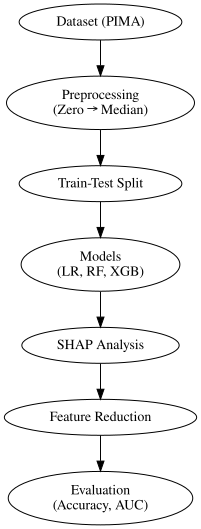

In [102]:
from graphviz import Digraph

dot = Digraph()

dot.node("A", "Dataset (PIMA)")
dot.node("B", "Preprocessing\n(Zero → Median)")
dot.node("C", "Train-Test Split")
dot.node("D", "Models\n(LR, RF, XGB)")
dot.node("E", "SHAP Analysis")
dot.node("F", "Feature Reduction")
dot.node("G", "Evaluation\n(Accuracy, AUC)")

dot.edges(["AB","BC","CD","DE","EF","FG"])

dot

In [103]:
!pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [104]:
!conda install -c conda-forge python-graphviz

/opt/conda/lib/python3.9/site-packages/conda/base/context.py:211: FutureWarning: Adding 'defaults' to channel list implicitly is deprecated and will be removed in 25.9. 

To remove this warning, please choose a default channel explicitly with conda's regular configuration system, e.g. by adding 'defaults' to the list of channels:

  conda config --add channels defaults

For more information see https://docs.conda.io/projects/conda/en/stable/user-guide/configuration/use-condarc.html

  deprecated.topic(
Retrieving notices: done

EnvironmentNotWritableError: The current user does not have write permissions to the target environment.
  environment location: /opt/conda/envs/anaconda-2025.12-py312
  uid: 2928727
  gid: 60000




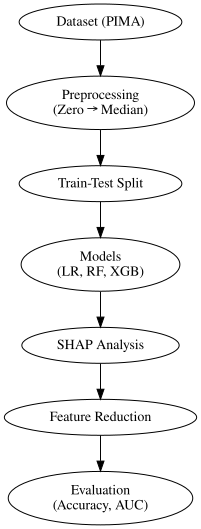

In [105]:
from graphviz import Digraph

dot = Digraph()

dot.node("A", "Dataset (PIMA)")
dot.node("B", "Preprocessing\n(Zero → Median)")
dot.node("C", "Train-Test Split")
dot.node("D", "Models\n(LR, RF, XGB)")
dot.node("E", "SHAP Analysis")
dot.node("F", "Feature Reduction")
dot.node("G", "Evaluation\n(Accuracy, AUC)")

dot.edges(["AB","BC","CD","DE","EF","FG"])

dot

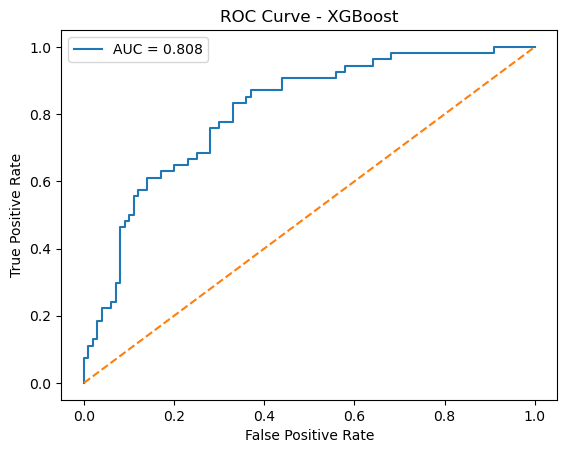

In [106]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_proba = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [108]:
import pandas as pd
import numpy as np

# This downloads the dataset directly from a reliable source
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

# Show the first few rows to confirm it works
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [109]:
!pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


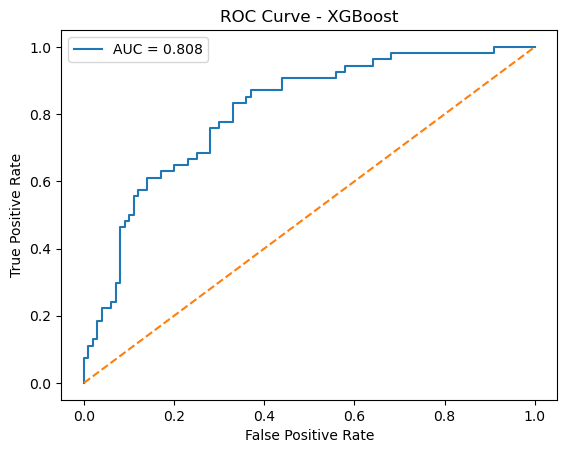

In [110]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_proba = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()